# Benchmarks for Microgrid environment

The notebook provides testing and comparison between deterministic policies and a pretrained RL agent strategies among the `MicroGridEnv` environment.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ../..

/home/andreabarisione/ErNESTO-gym


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from tqdm import tqdm
from collections import OrderedDict, defaultdict
from gymnasium.utils.env_checker import check_env
import gymnasium as gym
import copy

from ernestogym.envs.single_agent.env_new import MicroGridEnv
from ernestogym.envs.single_agent.utils import parameter_generator

In [3]:
sns.set_style('darkgrid')
plot_colors = sns.color_palette()
sns.set(font_scale=1.2)

alg_color = OrderedDict({
    'random': plot_colors[0],
    'only_market': plot_colors[1],
    'battery_first': plot_colors[2],
    '50-50': plot_colors[3],
    'ppo': plot_colors[4],
    'ppo_y': plot_colors[5]
})

alg_markers = OrderedDict({
    'random': '.',
    'only_market': 'o',
    'battery_first': 'v',
    '50-50': 'P',
    'ppo': '*',
    'ppo_y': '+'
})

alg_labels = {
    'random': 'Random',
    'only_market': 'OM',
    'battery_first': 'BF',
    '50-50': '50-50',
    'ppo': 'PPO',
    'ppo_y': 'PPO_{year_train}'
}

In [4]:
# IF RESULTS ARE ALREADY AVAILABLE, GO TO LAST CELLS TO LOAD THEM FROM JSON FILE AND DIRECTLY PLOT THEM!!

## Deterministic policies
Here we can evaluate different rule-based and deterministic policies.
Hereafter we will test:
1. random action policy
2. market-only policy
3. battery-first policy
5. 50/50 policy

In [5]:
params = parameter_generator(world_options='ernestogym/envs/single_agent/ijcnn_deg_test_cell.yaml')
params['battery']['params']['nominal_cost'] = 10.5
env = gym.make(id="ernestogym/micro_grid-v2", **{'settings':params})

++++++ INITIALIZING ENV +++++++
[INIT] Environment created with seed 74842


In [6]:
# Test profiles belonging to the test set
test_profiles = [i for i in range(370, 398)]
rewards = defaultdict(dict)

<h3> Random Policy: </h3>
The action is chosen randomly at each decision step.

In [7]:
# alg = 'random'
# rewards[alg] = {}
# profile = test_profiles[1]
# obs, info = env.reset(options={'eval_profile': str(profile)})
# done = False
# rewards[alg][profile] = {}
# rewards[alg][profile]['pure'] = []
# rewards[alg][profile]['weigh'] = []
# rewards[alg][profile]['norm'] = []

# while not done:
#     action = env.action_space.sample()  # Randomly select an action
#     obs, reward, terminated, truncated, info = env.step(action)  
#     done = terminated or truncated

In [8]:
# info.keys()

In [9]:
alg = 'random'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = env.action_space.sample()  # Randomly select an action
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
    rewards[alg][profile] = copy.deepcopy(info)

100%|██████████| 28/28 [01:12<00:00,  2.59s/it]


In [10]:
# import json

# with open('examples/single_agent/result_simulation_notebook/test_results_20251117_clip1.json', 'w') as f:
# #    json.dump(rewards, f, indent=4)
#     json.dump(rewards, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o) 


<h3> Only Market Policy: </h3>
The action chosen is always 0, meaning that the battery is never used.

In [11]:
alg = 'only_market'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = np.array([0]) # Only trading with market
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
    rewards[alg][profile] = copy.deepcopy(info)

100%|██████████| 28/28 [01:04<00:00,  2.31s/it]


In [12]:
# import json

# with open('examples/single_agent/result_simulation_notebook/test_results_20251117_clip1.json', 'w') as f:
# #    json.dump(rewards, f, indent=4)
#     json.dump(rewards, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o) 


<h3> Battery First Policy: </h3>
The action chosen is always 1, meaning that the battery is always used before interacting with the market.

In [13]:
alg = 'battery_first'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = np.array([1])  # Use the battery as much as possible 
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
    rewards[alg][profile] = copy.deepcopy(info)

100%|██████████| 28/28 [01:06<00:00,  2.36s/it]


In [14]:
# import json

# with open('examples/single_agent/result_simulation_notebook/test_results_20251117_clip1_2.json', 'w') as f:
# #    json.dump(rewards, f, indent=4)
#     json.dump(rewards, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o) 


<h3> 50-50 Policy: </h3>
The action chosen is always 0.5, meaning that the battery is never used.

In [15]:
rewards.keys()

dict_keys(['random', 'only_market', 'battery_first'])

In [16]:
alg = '50-50'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = np.array([0.5])  # Use the battery at 50%
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
    rewards[alg][profile] = copy.deepcopy(info)

100%|██████████| 28/28 [01:06<00:00,  2.37s/it]


In [17]:
# import json

# with open('examples/single_agent/result_simulation_notebook/test_results_20251117_clip1_3.json', 'w') as f:
# #    json.dump(rewards, f, indent=4)
#     json.dump(rewards, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o) 


### PPO agent
Here we load the previously created model `PPO_trained`.

In [18]:
# Uncomment the following line to install stable-baselines3
#!pip install stable-baselines3

In [19]:
from stable_baselines3 import PPO
from stable_baselines3.ppo import MlpPolicy
from stable_baselines3.common.env_util import make_vec_env

In [20]:
env = make_vec_env("ernestogym/micro_grid-v2", n_envs=1, env_kwargs={'settings':params})

alg = 'ppo'
rewards[alg] = {}

model = PPO(MlpPolicy, env, verbose=1)
vec_env = model.get_env()
# model = PPO.load("examples/single_agent/models/Weekly_experiment_longer_20250811_seed11.zip")
model = PPO.load("examples/single_agent/models/20251112_model.zip")


for profile in tqdm(test_profiles):
    vec_env.set_options({'eval_profile': str(profile)})
    obs = vec_env.reset()

    cumulated_reward = 0
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['norm'] = []
    rewards[alg][profile]['weigh'] = []
    done = False
    
    while not done:
        action, _states = model.predict(obs)
        obs, r, dones, info = vec_env.step(action)
        done = dones[0]
    rewards[alg][profile] = copy.deepcopy(info)

/home/andreabarisione/miniconda3/envs/ernesto-gym/lib/python3.11/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


++++++ INITIALIZING ENV +++++++
[INIT] Environment created with seed 74842
Using cpu device


100%|██████████| 28/28 [01:18<00:00,  2.81s/it]


In [21]:
# rewards[alg][370]

In [ ]:
env = make_vec_env("ernestogym/micro_grid-v2", n_envs=1, env_kwargs={'settings':params})

alg = 'ppo_y'

rewards[alg] = {}

model = PPO(MlpPolicy, env, verbose=1)
vec_env = model.get_env()
# model = PPO.load("examples/single_agent/models/Weekly_experiment_longer_20250811_seed11.zip")
# model = PPO.load("examples/single_agent/models/20251112_model.zip")
model = PPO.load("examples/single_agent/models/year_long_training_last_model.zip")


for profile in tqdm(test_profiles):
    vec_env.set_options({'eval_profile': str(profile)})
    obs = vec_env.reset()

    cumulated_reward = 0
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['norm'] = []
    rewards[alg][profile]['weigh'] = []
    done = False
    
    while not done:
        action, _states = model.predict(obs)
        obs, r, dones, info = vec_env.step(action)
        done = dones[0]
        print(info[])
    rewards[alg][profile] = copy.deepcopy(info)

/home/andreabarisione/miniconda3/envs/ernesto-gym/lib/python3.11/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


++++++ INITIALIZING ENV +++++++
[INIT] Environment created with seed 74842
Using cpu device


100%|██████████| 28/28 [01:17<00:00,  2.76s/it]


In [23]:
# import json
# with open('examples/single_agent/result_simulation_notebook/test_results_20251118_weejly_seed_74842.json', 'w') as f:
# #    json.dump(rewards, f, indent=4)
#     json.dump(rewards, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o) 


In [24]:
#import json

#with open('examples/microgrid/test_results.json', 'w') as f:
#    json.dump(rewards, f, indent=4)

## Result analysis
Here we compare the average cumulated reward across all the test profiles among the different methods.

In [25]:
# import json

# with open('examples/single_agent/result_simulation_notebook/test_results_20251117_clip01.json', 'r') as f:
#    rewards = json.load(f)

In [26]:
rewards['random'][370]

{'pure_reward_list': defaultdict(list,
             {'r_trad': [2.367223775113748e-05,
               0.00010930873814597726,
               0.0001144591435568385,
               1.2672532444431718e-05,
               1.76056420765762e-05,
               -1.790918121429979e-05,
               -1.6447959867306054e-05,
               -2.936134139147811e-05,
               -6.211995466881293e-05,
               -6.71714764286302e-05,
               -0.00011271530198431003,
               -0.0001920301054558999,
               -7.313119252859328e-05,
               -9.643145444060038e-05,
               -8.351080921586167e-05,
               -0.00011909334273724033,
               -0.00010915835647673866,
               -5.859121765314509e-05,
               -0.00010958699668647134,
               -8.296014209617099e-05,
               -7.477411770196113e-06,
               2.1509487213656125e-05,
               5.553306076907958e-05,
               6.190622644436081e-07,
               0.

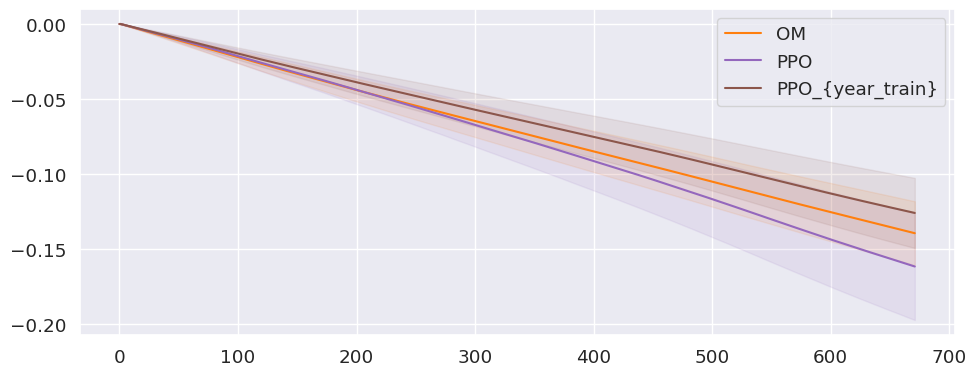

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

# alg_to_plot = ['random', 'only_market', 'battery_first', '50-50', 'ppo']
alg_to_plot = ['only_market', 'ppo', 'ppo_y']
for _, alg in enumerate(alg_to_plot):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['pure_reward_list']['r_deg'][i] for i in range(len(rewards[alg][profile][0]['pure_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['pure_reward_list']['r_deg'][i] for i in range(len(rewards[alg][profile]['pure_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

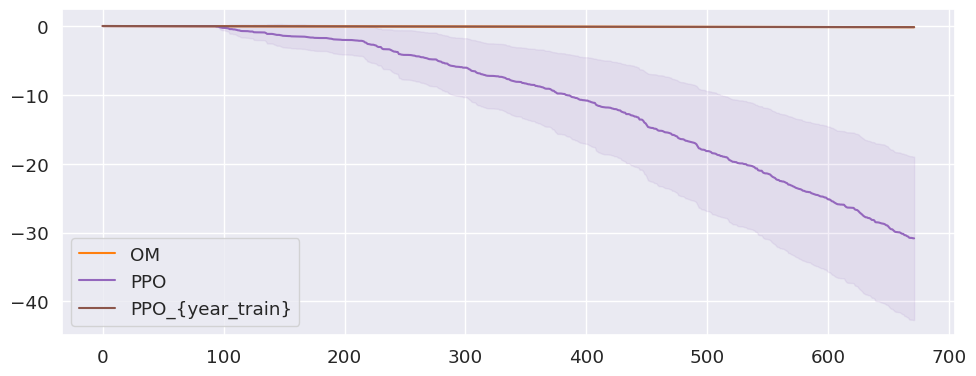

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

# alg_to_plot = ['random', 'only_market', 'battery_first', '50-50', 'ppo', 'ppo_y']
# alg_to_plot = ['only_market', 'ppo']

for _, alg in enumerate(alg_to_plot):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['pure_reward_list']['r_deg'][i] + rewards[alg][profile][0]['pure_reward_list']['r_clip'][i] + rewards[alg][profile][0]['pure_reward_list']['r_trad'][i] for i in range(len(rewards[alg][profile][0]['pure_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['pure_reward_list']['r_deg'][i] +rewards[alg][profile]['pure_reward_list']['r_clip'][i] + rewards[alg][profile]['pure_reward_list']['r_trad'][i] for i in range(len(rewards[alg][profile]['pure_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

In [29]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

# alg = 'battery_first'
# cum_rewards_pure = []
# for profile in rewards[alg].keys():
#     if alg == 'ppo' or alg == 'ppo_y':
#         cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['pure_reward_list']['r_deg'][i] + rewards[alg][profile][0]['pure_reward_list']['r_trad'][i] + rewards[alg][profile][0]['pure_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile][0]['pure_reward_list']['r_deg']))]))
    
#     else:
#         cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['pure_reward_list']['r_deg'][i] + rewards[alg][profile]['pure_reward_list']['r_trad'][i] + rewards[alg][profile]['pure_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile]['pure_reward_list']['r_deg']))]))


# means_pure = np.mean(cum_rewards_pure, axis=0)
# stds_pure = np.std(cum_rewards_pure, axis=0)
# ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

# ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
# ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
# ax.legend()

In [30]:
rewards.keys()

dict_keys(['random', 'only_market', 'battery_first', '50-50', 'ppo', 'ppo_y'])

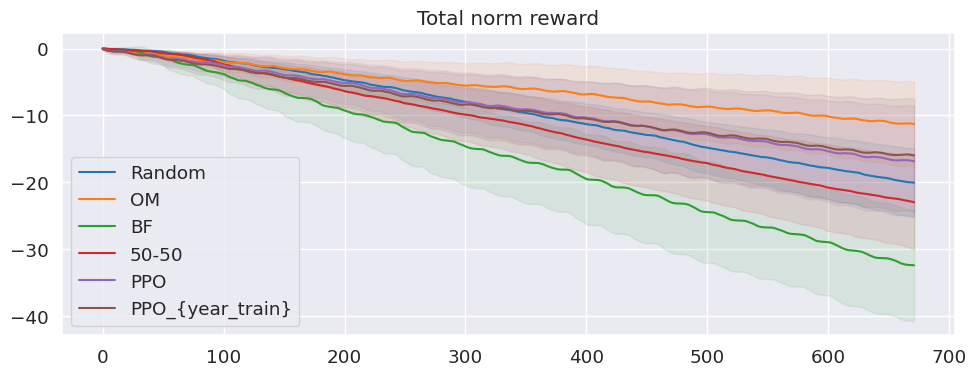

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)
# alg_to_plot = ['only_market','ppo']
# 385 393
# profiles = [385]
for _, alg in enumerate(rewards.keys()):
# for _, alg in enumerate(alg_to_plot):
    cum_rewards_pure = []
    # for profile in profiles:
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['norm_reward_list']['r_deg'][i] + rewards[alg][profile][0]['norm_reward_list']['r_trad'][i] + rewards[alg][profile][0]['norm_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile][0]['norm_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['norm_reward_list']['r_deg'][i] + rewards[alg][profile]['norm_reward_list']['r_trad'][i] + rewards[alg][profile]['norm_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile]['norm_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))
    ax.set_title('Total norm reward')
    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

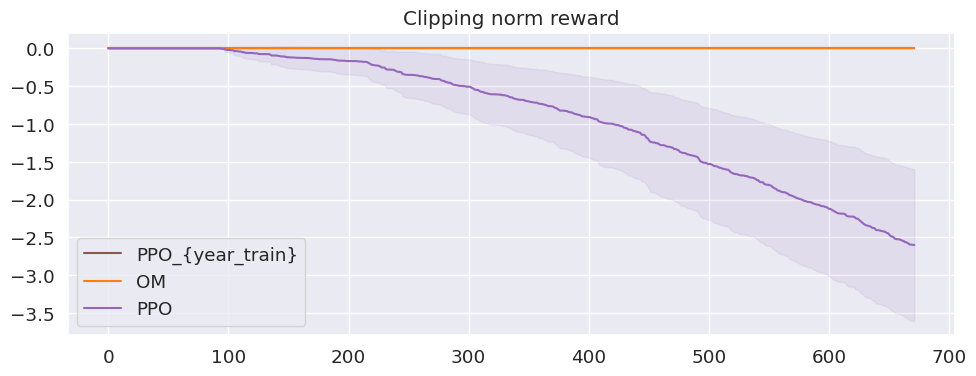

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)
alg_to_plot = ['ppo_y','only_market','ppo']
# for _, alg in enumerate(rewards.keys()):
for _, alg in enumerate(alg_to_plot):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['norm_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile][0]['pure_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['norm_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile]['pure_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])
    ax.set_title('Clipping norm reward')   
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

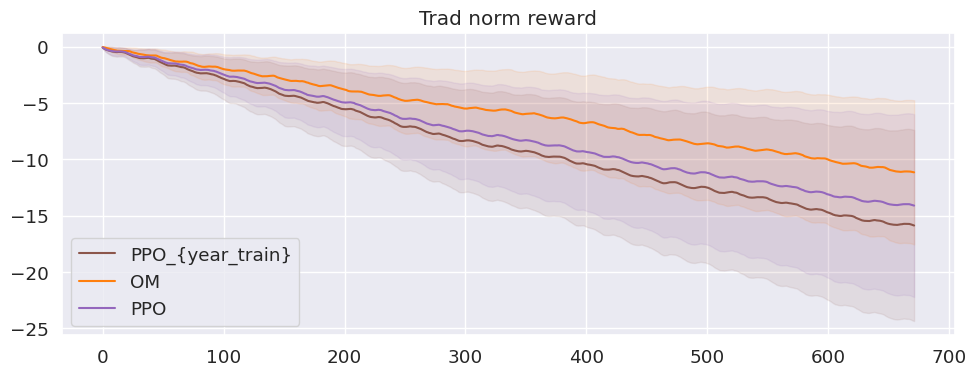

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)
alg_to_plot = ['ppo_y','only_market','ppo']
for _, alg in enumerate(alg_to_plot):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['norm_reward_list']['r_trad'][i] for i in range(len(rewards[alg][profile][0]['pure_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['norm_reward_list']['r_trad'][i] for i in range(len(rewards[alg][profile]['pure_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))
    ax.set_title('Trad norm reward')
    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

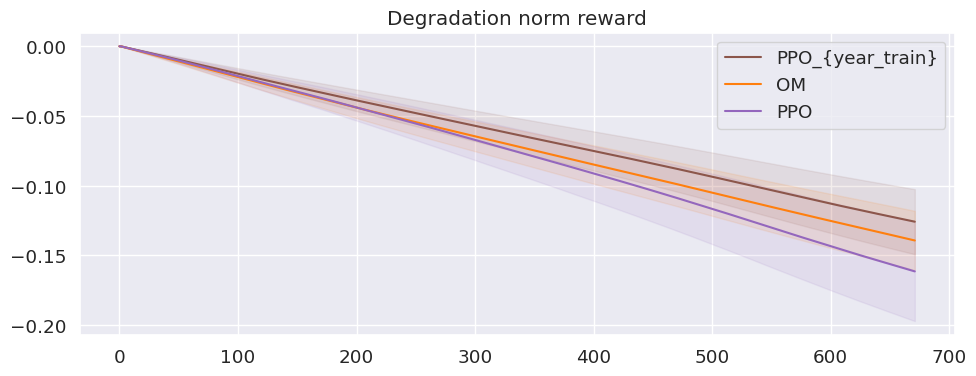

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)
alg_to_plot = ['ppo_y','only_market','ppo']
for _, alg in enumerate(alg_to_plot):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['norm_reward_list']['r_deg'][i] for i in range(len(rewards[alg][profile][0]['pure_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['norm_reward_list']['r_deg'][i] for i in range(len(rewards[alg][profile]['pure_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])
    ax.set_title('Degradation norm reward')   
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

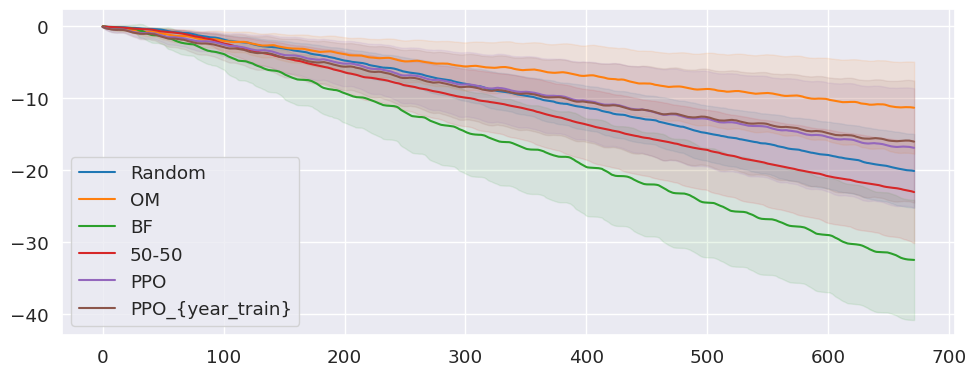

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

for _, alg in enumerate(rewards.keys()):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile][0]['weighted_reward_list']['r_deg'][i] + rewards[alg][profile][0]['weighted_reward_list']['r_trad'][i] + rewards[alg][profile][0]['weighted_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile][0]['weighted_reward_list']['r_deg']))]))
        
        else:
            cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['weighted_reward_list']['r_deg'][i] + rewards[alg][profile]['weighted_reward_list']['r_trad'][i] + rewards[alg][profile]['weighted_reward_list']['r_clip'][i] for i in range(len(rewards[alg][profile]['weighted_reward_list']['r_deg']))]))


    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

TypeError: list indices must be integers or slices, not str

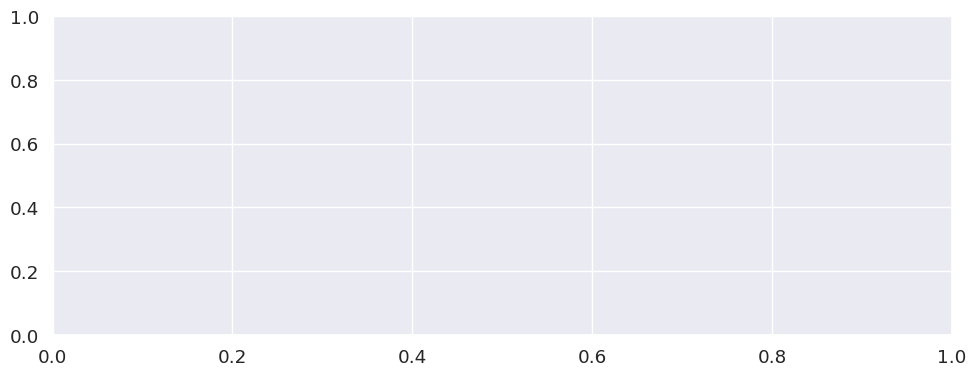

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

# for i, alg in enumerate(rewards.keys()):
cum_rewards_pure = []
cum_rewards_norm = []
cum_rewards_weigh = []
for profile in rewards[alg].keys():
    # cum_rewards.append(np.cumsum([rewards[alg][profile]['pure'][i][0] + rewards[alg][profile]['pure'][i][1] + rewards[alg][profile]['pure'][i][2] for i in range(len(rewards[alg][profile]['pure']))]))
    # cum_rewards.append(np.cumsum([rewards['ppo'][profile]['pure'][i][0] + rewards['ppo'][profile]['pure'][i][1] + rewards['ppo'][profile]['pure'][i][2] for i in range(len(rewards['ppo'][profile]['pure']))]))    
    # cum_rewards.append(np.cumsum([rewards['ppo'][profile]['norm'][i][0] + rewards['ppo'][profile]['norm'][i][1] + rewards['ppo'][profile]['norm'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    
    cum_rewards_pure.append(np.cumsum([rewards['ppo'][profile]['pure'][i][0] + rewards['ppo'][profile]['pure'][i][1] + rewards['ppo'][profile]['pure'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    
    cum_rewards_norm.append(np.cumsum([rewards['ppo'][profile]['norm'][i][0] + rewards['ppo'][profile]['norm'][i][1] + rewards['ppo'][profile]['norm'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    
    cum_rewards_weigh.append(np.cumsum([rewards['ppo'][profile]['weigh'][i][0] + rewards['ppo'][profile]['weigh'][i][1] + rewards['ppo'][profile]['weigh'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    

means_pure = np.mean(cum_rewards_pure, axis=0)
stds_pure = np.std(cum_rewards_pure, axis=0)
ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

means_norm = np.mean(cum_rewards_norm, axis=0)
stds_norm = np.std(cum_rewards_norm, axis=0)
ci_norm = 1.96 * stds_norm/np.sqrt(len(rewards[alg].keys()))

means_weigh = np.mean(cum_rewards_weigh, axis=0)
stds_weigh = np.std(cum_rewards_weigh, axis=0)
ci_weigh = 1.96 * stds_weigh/np.sqrt(len(rewards[alg].keys()))


ax.plot(means_pure, label='PPO_pure', color=alg_color[alg])        
ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
# ax.legend()

ax.plot(means_norm, label='PPO_norm')        
ax.fill_between(range(len(means_norm)), means_norm + ci_norm, means_norm - ci_norm, alpha=0.1)
# ax.legend()

ax.plot(means_weigh, label='PPO_weigh')        
ax.fill_between(range(len(means_weigh)), means_weigh + ci_weigh, means_weigh - ci_weigh, alpha=0.1)
ax.legend()

In [ ]:
box_data = {}
colors = []

for alg in rewards.keys():
    box_data[alg_labels[alg]] = []
    
    for profile in rewards[alg].keys():
        if alg == 'ppo' or alg == 'ppo_y':
            total_trad = np.sum([rewards[alg][profile][0]['weighted_reward_list']['r_trad'][i] for i in range(len(rewards[alg][profile][0]['weighted_reward_list']))])
            total_deg = np.sum([rewards[alg][profile][0]['weighted_reward_list']['r_deg'][i] for i in range(len(rewards[alg][profile][0]['weighted_reward_list']))])
            box_data[alg_labels[alg]].append(total_trad + total_deg)

        else:
            total_trad = np.sum([rewards[alg][profile]['weighted_reward_list']['r_trad'][i] for i in range(len(rewards[alg][profile]['weighted_reward_list']))])
            total_deg = np.sum([rewards[alg][profile]['weighted_reward_list']['r_deg'][i] for i in range(len(rewards[alg][profile]['weighted_reward_list']))])
            box_data[alg_labels[alg]].append(total_trad + total_deg)


    colors.append(alg_color[alg])
        
fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
box_plot = sns.boxplot(box_data, gap=.1, palette=colors, width=.8)

medians = [np.mean(values) for key, values in box_data.items()]
vertical_offset = -130 # offset from median for display

for xtick, alg in zip(box_plot.get_xticks(), rewards.keys()):
    box_plot.text(xtick, 
                  vertical_offset, 
                  round(medians[xtick]), 
                  horizontalalignment='center',
                  size='x-small', 
                  color=alg_color[alg], 
                  weight='semibold')

In [ ]:
medians